⏳ Đang chuẩn hoá dữ liệu (StandardScaler)...
⏳ Đang huấn luyện K-Means với K=4...
✅ Phân cụm xong! Silhouette Score: 0.3684
⏳ Đang tạo hồ sơ cụm (Profiling)...


,Temperature (C),Humidity,Wind Speed (km/h),Pressure (millibars),Số ngày
Cluster,,,,,
0,7.40,0.86,7.62,1018.24,52087
1,22.55,0.50,10.36,1015.77,26756
2,9.10,0.72,21.57,1013.97,16322
3,10.71,0.73,12.76,0.00,1288


⏳ Đang giảm chiều bằng PCA để vẽ biểu đồ...


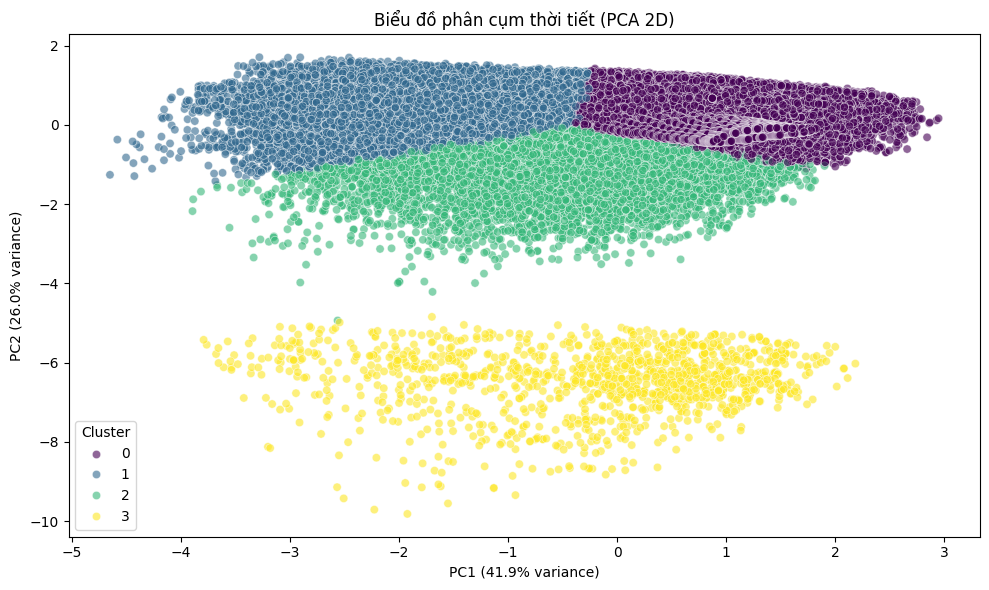

In [1]:
import os
import sys
import pandas as pd

if os.getcwd().endswith('notebooks'):
    os.chdir('..')
sys.path.append(os.getcwd())

from src.clustering_models import WeatherClustering
import yaml

# 1. Đọc dữ liệu
with open("configs/params.yaml", "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)
df_clean = pd.read_csv(config['data']['processed_path'])

# 2. Khởi tạo module phân cụm
cluster_model = WeatherClustering()

# 3. Chuẩn hoá dữ liệu (Yêu cầu bắt buộc)
X_scaled = cluster_model.preprocess_for_clustering(df_clean)

# 4. Huấn luyện mô hình K-Means
labels = cluster_model.run_kmeans(X_scaled)

# 5. Xem hồ sơ cụm (Profiling)
profile = cluster_model.get_cluster_profile(df_clean, labels)
display(profile)

# 6. Trực quan hoá bằng PCA
cluster_model.plot_clusters_pca(X_scaled, labels)